## Instancia toy de slotting

Queremos asignar productos a ubicaciones dentro de un warehouse.

Para eso construimos cuatro elementos:

---

### 1. Afinidad entre productos $A $

- $A_{ij} $: cantidad de órdenes donde aparecen juntos los productos $i$ y $j$

Cómo se calcula:

- para cada orden vemos qué productos aparecen
- contamos cuántas veces aparece cada par de productos

Interpretación:

- si $A_{ij} $ es grande, esos productos se compran juntos seguido
- conviene ubicarlos cerca

---

### 2. Importancia de productos $f $

- $f_i $: cantidad de órdenes en las que aparece el producto $i$

Cómo se calcula:

- contamos en cuántas órdenes aparece cada producto

Interpretación:

- productos con mayor $f_i $ son más importantes
- conviene ponerlos en mejores ubicaciones

---

### 3. Costo de ubicaciones $c $

Las ubicaciones están dispuestas en una grilla de filas y columnas.

Definimos un depot en la fila superior y en la columna central.

- $c_k $: costo de usar la ubicación $k$

Cómo se calcula:

- el costo de una ubicación es su distancia Manhattan al depot

Si la ubicación $k$ está en la posición $(r_k, c_k)$ y el depot está en $(r_d, c_d)$, entonces:

$$
c_k = |r_k - r_d| + |c_k - c_d|
$$

Interpretación:

- ubicaciones más cerca del depot son mejores
- ubicaciones más lejos del depot son peores

---

### 4. Distancia entre ubicaciones $ D $

- $ D_{kl} $: distancia entre las ubicaciones $k$ y $l$

Cómo se calcula:

Cada ubicación está en una grilla, con una fila y una columna.

Suponemos que:

- si dos ubicaciones están en la misma columna, se puede mover directamente dentro de ese pasillo
- si están en columnas distintas, hay que salir al pasillo central, recorrerlo y entrar al otro pasillo

Entonces:

- si $c_k = c_l$,

$$
D_{kl} = |r_k - r_l|
$$

- si $c_k \neq c_l$,

$$
D_{kl} = (r_k + 1) + |c_k - c_{\text{mid}}| + |c_l - c_{\text{mid}}| + (r_l + 1)
$$

donde $c_{\text{mid}}$ es la columna central.

Interpretación:

- cambiar de columna es más caro, porque obliga a pasar por el medio
- moverse dentro de la misma columna es más barato

---

## Idea general

Queremos una asignación de productos a ubicaciones tal que:

- productos importantes estén en ubicaciones buenas
- productos que se compran juntos estén cerca

Estos dos criterios se combinan después en la función objetivo del modelo.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd

from src.build_instance import (
    load_synthetic_data,
    build_toy_instance,
    summarize_products,
    summarize_locations,
)

In [3]:
data_dir = "../data/synthetic_dataset"

products_df, orders_df, order_lines_df = load_synthetic_data(data_dir)

print(products_df.head(),end="\n\n")
print(orders_df.head(),end="\n\n")
print(order_lines_df.head())

   product_id product_name group_ids  is_popular
0           0         P000         0           0
1           1         P001         3           0
2           2         P002         3           0
3           3         P003         2           0
4           4         P004         2           0

   order_id  main_group  n_items
0         0           1        3
1         1           0        3
2         2           1        4
3         3           1        3
4         4           0        5

   order_id  line_no  product_id  quantity
0         0        1          28         3
1         0        2          31         3
2         0        3          36         1
3         1        1          74         1
4         1        2          89         2


In [4]:
print("Products:", products_df.shape)
print("Orders:", orders_df.shape)
print("Order lines:", order_lines_df.shape)

print("\nColumnas order_lines:")
print(order_lines_df.columns.tolist())

Products: (100, 4)
Orders: (5000, 3)
Order lines: (19995, 4)

Columnas order_lines:
['order_id', 'line_no', 'product_id', 'quantity']


In [5]:
instance = build_toy_instance(
    order_lines=order_lines_df,
    n_rows=4,
    n_cols=5,
    affinity_method="cooccurrence",
)

In [6]:
print("A (afinidad):", instance.affinity_matrix.shape)
print("f (frecuencia):", instance.product_frequency.shape)
print("D (distancias):", instance.location_distances.shape)
print("c (costos):", instance.location_costs.shape)

print("\n#products:", len(instance.product_ids))
print("#locations:", len(instance.location_ids))


A (afinidad): (100, 100)
f (frecuencia): (100,)
D (distancias): (20, 20)
c (costos): (20,)

#products: 100
#locations: 20


In [7]:
# inspeccionar afinidad
A = instance.affinity_matrix

# top pares más fuertes
pairs = []

n = A.shape[0]
for i in range(n):
    for j in range(i + 1, n):
        pairs.append((i, j, A[i, j]))

pairs = sorted(pairs, key=lambda x: -x[2])

pairs[:10]

[(31, 95, np.float64(45.0)),
 (22, 99, np.float64(43.0)),
 (25, 61, np.float64(39.0)),
 (10, 75, np.float64(37.0)),
 (10, 69, np.float64(35.0)),
 (31, 67, np.float64(34.0)),
 (31, 93, np.float64(34.0)),
 (31, 84, np.float64(31.0)),
 (66, 91, np.float64(30.0)),
 (69, 75, np.float64(30.0))]

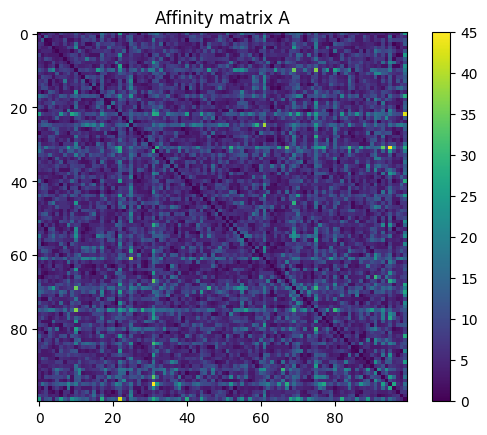

In [8]:
import matplotlib.pyplot as plt

plt.imshow(instance.affinity_matrix)
plt.colorbar()
plt.title("Affinity matrix A")
plt.show()

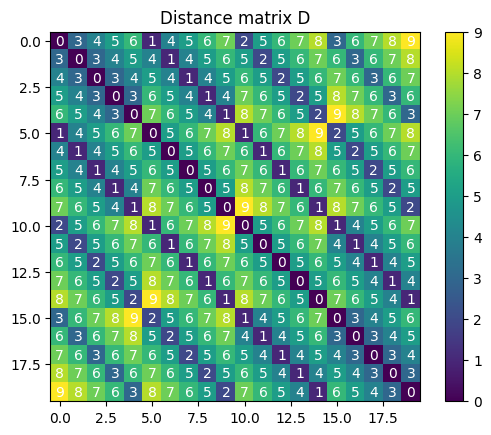

In [9]:
D = instance.location_distances

plt.imshow(D)

for i in range(D.shape[0]):
    for j in range(D.shape[1]):
        val = D[i, j]
        plt.text(j, i, f"{val:.0f}", ha="center", va="center", color="white")
plt.colorbar()
plt.title("Distance matrix D")
plt.show()

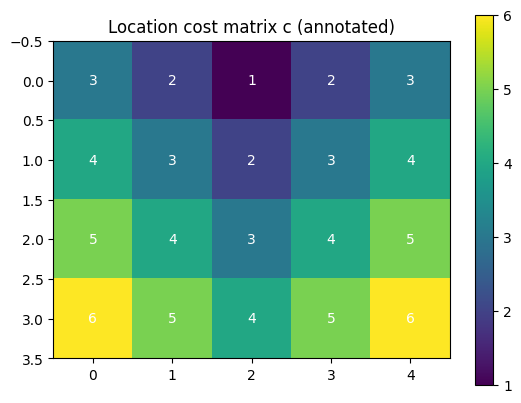

In [10]:
from src.build_wh import build_location_grid

n_rows = instance.n_rows
n_cols = instance.n_cols

grid = build_location_grid(n_rows, n_cols)

df_plot = grid.copy()
df_plot["cost"] = instance.location_costs

cost_matrix = df_plot.pivot(index="row", columns="col", values="cost")

plt.imshow(cost_matrix)

for i in range(n_rows):
    for j in range(n_cols):
        val = cost_matrix.iloc[i, j]
        plt.text(j, i, f"{val:.0f}", ha="center", va="center", color="white")

plt.colorbar()
plt.title("Location cost matrix c (annotated)")
plt.show()

In [11]:
df_products = summarize_products(instance)
df_locations = summarize_locations(instance)

print("Top productos:")
print(df_products.head(5))

print("\nMejores ubicaciones:")
print(df_locations.sort_values("location_cost").head(5))

Top productos:
   product_id  frequency
0          99      376.0
1          22      369.0
2          31      365.0
3          75      361.0
4          95      342.0

Mejores ubicaciones:
   location_id  location_cost
2            2            1.0
1            1            2.0
3            3            2.0
7            7            2.0
0            0            3.0


In [12]:
print("Productos:", len(instance.product_ids))
print("Ubicaciones:", len(instance.location_ids))

Productos: 100
Ubicaciones: 20


In [13]:
np.max(instance.location_distances)

np.float64(9.0)

## Experimento 1

elijo $p$ productos
elijo $m$ ubicaciones

primero asumo $p \leqslant m$

In [14]:
n_products_toy = 8

selected_idx = summarize_products(instance).head(n_products_toy)["product_id"].to_numpy()

In [15]:
A_toy = instance.affinity_matrix[np.ix_(selected_idx, selected_idx)]
f_toy = instance.product_frequency[selected_idx]

print("A_toy:", A_toy.shape)
print("f_toy:", f_toy.shape)

A_toy: (8, 8)
f_toy: (8,)


In [16]:
n_locations_toy = 8

best_location_idx = np.argsort(instance.location_costs)[:n_locations_toy]

location_ids_toy = instance.location_ids[best_location_idx]
c_toy = instance.location_costs[best_location_idx]
D_toy = instance.location_distances[np.ix_(best_location_idx, best_location_idx)]

print("location_ids_toy:", location_ids_toy)
print("c_toy:", c_toy.shape)
print("D_toy:", D_toy.shape)

location_ids_toy: [2 1 3 7 0 4 6 8]
c_toy: (8,)
D_toy: (8, 8)


In [17]:
print("Productos seleccionados:", selected_idx)
print("Ubicaciones seleccionadas:", location_ids_toy)

print("\nA_toy:")
print(A_toy)

print("\nf_toy:")
print(f_toy)

print("\nc_toy:")
print(c_toy)

print("\nD_toy:")
print(D_toy)

Productos seleccionados: [99 22 31 75 95 25 61 69]
Ubicaciones seleccionadas: [2 1 3 7 0 4 6 8]

A_toy:
[[ 0. 43. 28. 12. 16. 16. 14. 19.]
 [43.  0. 28. 25. 17. 14. 15. 11.]
 [28. 28.  0. 22. 45. 17. 15.  9.]
 [12. 25. 22.  0. 14. 24. 15. 30.]
 [16. 17. 45. 14.  0. 16. 15. 16.]
 [16. 14. 17. 24. 16.  0. 39. 19.]
 [14. 15. 15. 15. 15. 39.  0. 17.]
 [19. 11.  9. 30. 16. 19. 17.  0.]]

f_toy:
[376. 369. 365. 361. 342. 336. 323. 316.]

c_toy:
[1. 2. 2. 2. 3. 3. 3. 3.]

D_toy:
[[0. 3. 3. 1. 4. 4. 4. 4.]
 [3. 0. 4. 4. 3. 5. 1. 5.]
 [3. 4. 0. 4. 5. 3. 5. 1.]
 [1. 4. 4. 0. 5. 5. 5. 5.]
 [4. 3. 5. 5. 0. 6. 4. 6.]
 [4. 5. 3. 5. 6. 0. 6. 4.]
 [4. 1. 5. 5. 4. 6. 0. 6.]
 [4. 5. 1. 5. 6. 4. 6. 0.]]


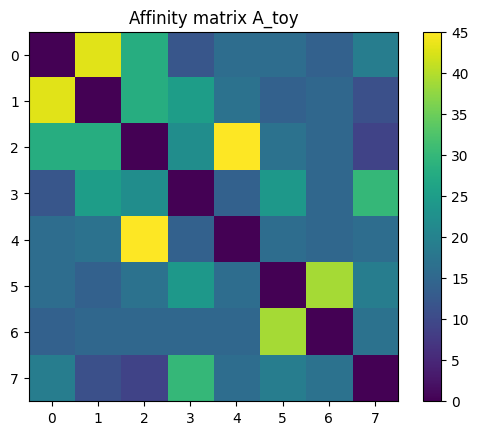

In [18]:
plt.imshow(A_toy)
plt.colorbar()
plt.title("Affinity matrix A_toy")
plt.show()

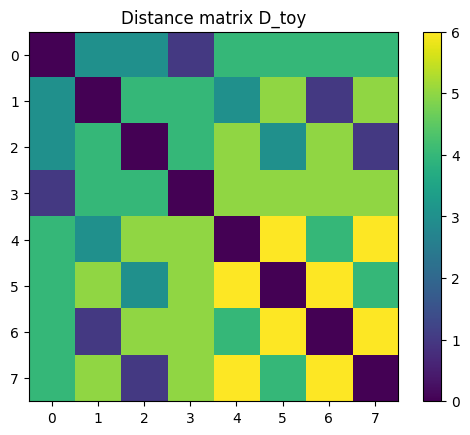

In [19]:
plt.imshow(D_toy)
plt.colorbar()
plt.title("Distance matrix D_toy")
plt.show()

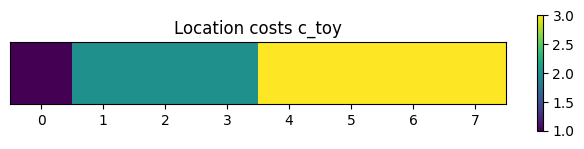

In [20]:
plt.figure(figsize=(8, 1.5))
plt.imshow(c_toy.reshape(1, -1))
plt.colorbar()
plt.title("Location costs c_toy")
plt.yticks([])
plt.show()

In [21]:

grid = build_location_grid(instance.n_rows, instance.n_cols)

df_toy_locations = grid[grid["location_id"].isin(location_ids_toy)].copy()
df_toy_locations["toy_idx"] = range(len(df_toy_locations))

df_toy_locations = df_toy_locations.set_index("location_id").loc[location_ids_toy].reset_index()

df_toy_locations_sorted = (
    df_toy_locations
    .sort_values(["row", "col"])
    .reset_index(drop=True)
)

location_ids_toy_sorted = df_toy_locations_sorted["location_id"].to_numpy()

D_toy_sorted = pd.DataFrame(
    instance.location_distances[np.ix_(location_ids_toy_sorted, location_ids_toy_sorted)],
    index=location_ids_toy_sorted,
    columns=location_ids_toy_sorted,
)

df_toy_locations_sorted, D_toy_sorted

(   location_id  row  col  toy_idx
 0            0    0    0        0
 1            1    0    1        1
 2            2    0    2        2
 3            3    0    3        3
 4            4    0    4        4
 5            6    1    1        5
 6            7    1    2        6
 7            8    1    3        7,
      0    1    2    3    4    6    7    8
 0  0.0  3.0  4.0  5.0  6.0  4.0  5.0  6.0
 1  3.0  0.0  3.0  4.0  5.0  1.0  4.0  5.0
 2  4.0  3.0  0.0  3.0  4.0  4.0  1.0  4.0
 3  5.0  4.0  3.0  0.0  3.0  5.0  4.0  1.0
 4  6.0  5.0  4.0  3.0  0.0  6.0  5.0  4.0
 6  4.0  1.0  4.0  5.0  6.0  0.0  5.0  6.0
 7  5.0  4.0  1.0  4.0  5.0  5.0  0.0  5.0
 8  6.0  5.0  4.0  1.0  4.0  6.0  5.0  0.0)

In [22]:
products_toy = selected_idx.copy()
locations_toy = location_ids_toy.copy()

I = range(len(products_toy))
K = range(len(locations_toy))

print("Productos toy:", products_toy)
print("Ubicaciones toy:", locations_toy)

Productos toy: [99 22 31 75 95 25 61 69]
Ubicaciones toy: [2 1 3 7 0 4 6 8]


In [23]:
A = A_toy.copy()   # afinidad producto-producto
f = f_toy.copy()   # importancia/frecuencia de productos
c = c_toy.copy()   # costo de ubicaciones
D = D_toy.copy()   # distancia entre ubicaciones

lambda_weight = 0.5

## Formulación toy

### Variable de decisión

Definimos una variable binaria:

$$
x_{ik} =
\begin{cases}
1 & \text{si el producto } i \text{ se asigna a la ubicación } k \\
0 & \text{en otro caso}
\end{cases}
$$

### Restricciones básicas

Para este toy example vamos a asumir:

- cada producto se asigna a una única ubicación
- cada ubicación puede recibir a lo sumo un producto

Es decir:

$$
\sum_{k \in K} x_{ik} = 1 \quad \forall i
$$

$$
\sum_{i \in I} x_{ik} \le 1 \quad \forall k
$$

### Función objetivo

Queremos balancear dos criterios:

1. **productos importantes en ubicaciones buenas**

$$
\sum_{i \in I}\sum_{k \in K} f_i c_k x_{ik}
$$

2. **productos afines en ubicaciones cercanas**

$$
\sum_{i \in I}\sum_{j \in I}\sum_{k \in K}\sum_{l \in K}
A_{ij} D_{kl} x_{ik} x_{jl}
$$

Entonces la función objetivo toy es:

$$
\min \;
\lambda \sum_{i \in I}\sum_{k \in K} f_i c_k x_{ik}
+
(1-\lambda)\sum_{i \in I}\sum_{j \in I}\sum_{k \in K}\sum_{l \in K}
A_{ij} D_{kl} x_{ik} x_{jl}
$$

donde $ \lambda \in [0,1] $ controla el peso relativo entre ambos términos.

In [29]:
n_products = len(products_toy)
n_locations = len(locations_toy)

print(n_products, n_locations)

8 8


In [40]:
import os
import gurobipy as gp
from gurobipy import GRB

os.environ["GRB_WLSACCESSID"] = "8f50bd08-d0fd-427d-aaab-c81b8ea6d04b"
os.environ["GRB_WLSSECRET"] = "bdba46fa-deda-4a94-85ff-fc272bf7e78d"
os.environ["GRB_LICENSEID"] = "2805866"

In [42]:
m = gp.Model("slotting_qap")

# variables binarias x[i,k]
x = {}
for i in I:
    for k in K:
        x[i, k] = m.addVar(vtype=GRB.BINARY, name=f"x_{i}_{k}")

# cada producto va a exactamente una ubicación
for i in I:
    m.addConstr(
        gp.quicksum(x[i, k] for k in K) == 1,
        name=f"assign_product_{i}"
    )

# cada ubicación recibe a lo sumo un producto
for k in K:
    m.addConstr(
        gp.quicksum(x[i, k] for i in I) <= 1,
        name=f"capacity_location_{k}"
    )

# término lineal
linear_term = gp.quicksum(
    f[i] * c[k] * x[i, k]
    for i in I
    for k in K
)

# término cuadrático
quadratic_term = gp.quicksum(
    A[i, j] * D[k, l] * x[i, k] * x[j, l]
    for i in I
    for j in I
    for k in K
    for l in K
)

# objetivo
m.setObjective(
    lambda_weight * linear_term +
    (1 - lambda_weight) * quadratic_term,
    GRB.MINIMIZE
)

m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 7 5700G with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 16 rows, 64 columns and 128 nonzeros (Min)
Model fingerprint: 0x2bd6fb31
Model has 64 linear objective coefficients
Model has 1568 quadratic objective terms
Variable types: 0 continuous, 64 integer (64 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+02, 6e+02]
  QObjective range [2e+01, 5e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 5577.5000000
Presolve time: 0.03s
Presolved: 1584 rows, 1632 columns, 4832 nonzeros
Variable types: 0 continuous, 1632 integer (1632 binary)

Root relaxation: objective 3.259667e+03, 75 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      